In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

print("Anomaly detection environment ready!")

Anomaly detection environment ready!


In [2]:
data_path = "../data/CICIDS2017/ml_ready/cicids2017_binary_ml_ready.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

Dataset loaded successfully!
Dataset shape: (288277, 79)

Columns: 79


In [3]:
print("Label distribution:")
print(df["Binary_Label"].value_counts())

print("\nLabel meaning:")
print("0 = BENIGN")
print("1 = ATTACK")

Label distribution:
Binary_Label
0    200000
1     88277
Name: count, dtype: int64

Label meaning:
0 = BENIGN
1 = ATTACK


In [4]:
# Select only normal (BENIGN) traffic for training
benign_data = df[df["Binary_Label"] == 0].copy()

print("Benign dataset shape:", benign_data.shape)
print("Benign samples:", len(benign_data))

Benign dataset shape: (200000, 79)
Benign samples: 200000


In [5]:
# Remove non-feature columns
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label",
    "Binary_Label"
]

X_benign = benign_data.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Feature matrix shape:", X_benign.shape)
print("Number of features:", X_benign.shape[1])

print("\nNon-numeric columns:")
print(X_benign.select_dtypes(exclude=np.number).columns.tolist())

Feature matrix shape: (200000, 78)
Number of features: 78

Non-numeric columns:
[]


In [6]:
X_benign = X_benign.replace([np.inf, -np.inf], np.nan)

print("Missing values before cleaning:",
      X_benign.isnull().sum().sum())

X_benign = X_benign.dropna()

print("Feature matrix after cleaning:", X_benign.shape)
print("Missing values after cleaning:",
      X_benign.isnull().sum().sum())

Missing values before cleaning: 0
Feature matrix after cleaning: (200000, 78)
Missing values after cleaning: 0


In [7]:
sample_size = min(100000, len(X_benign))

X_anomaly_train = X_benign.sample(
    n=sample_size,
    random_state=42
)

print("Samples used for Isolation Forest:",
      X_anomaly_train.shape[0])

Samples used for Isolation Forest: 100000


In [8]:
isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")

isolation_model.fit(X_anomaly_train)

print("Isolation Forest training completed!")

Training Isolation Forest...
Isolation Forest training completed!


In [9]:
X_all = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

X_all = X_all.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_rows = X_all.notna().all(axis=1)

X_all = X_all.loc[valid_rows]
y_all = df.loc[valid_rows, "Binary_Label"]

print("Evaluation samples:", X_all.shape[0])

anomaly_predictions = isolation_model.predict(X_all)

print("Predictions completed!")

Evaluation samples: 288277
Predictions completed!


In [10]:
anomaly_labels = np.where(
    anomaly_predictions == -1,
    1,
    0
)

print("Anomaly prediction distribution:")
print(pd.Series(anomaly_labels).value_counts())

print("\n0 = Normal")
print("1 = Anomaly")

Anomaly prediction distribution:
0    231005
1     57272
Name: count, dtype: int64

0 = Normal
1 = Anomaly


In [11]:
print("Actual labels:")
print(y_all.value_counts())

print("\nDetected labels:")
print(pd.Series(anomaly_labels).value_counts())

Actual labels:
Binary_Label
0    200000
1     88277
Name: count, dtype: int64

Detected labels:
0    231005
1     57272
Name: count, dtype: int64


In [12]:
cm_anomaly = confusion_matrix(
    y_all,
    anomaly_labels
)

print("Confusion Matrix:")
print(cm_anomaly)

Confusion Matrix:
[[180053  19947]
 [ 50952  37325]]


In [13]:
print(
    classification_report(
        y_all,
        anomaly_labels,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      BENIGN       0.78      0.90      0.84    200000
      ATTACK       0.65      0.42      0.51     88277

    accuracy                           0.75    288277
   macro avg       0.72      0.66      0.67    288277
weighted avg       0.74      0.75      0.74    288277



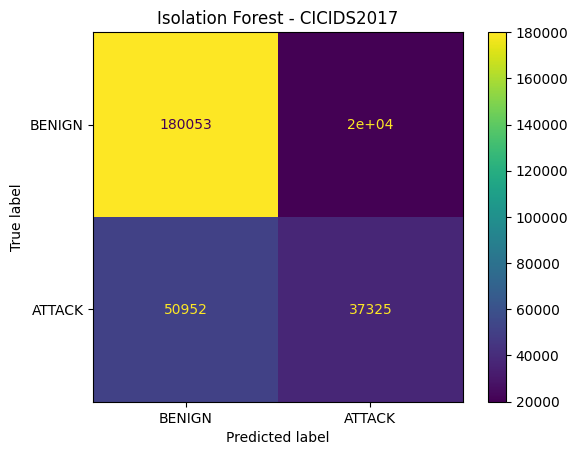

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_anomaly,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()

plt.title("Isolation Forest - CICIDS2017")
plt.show()

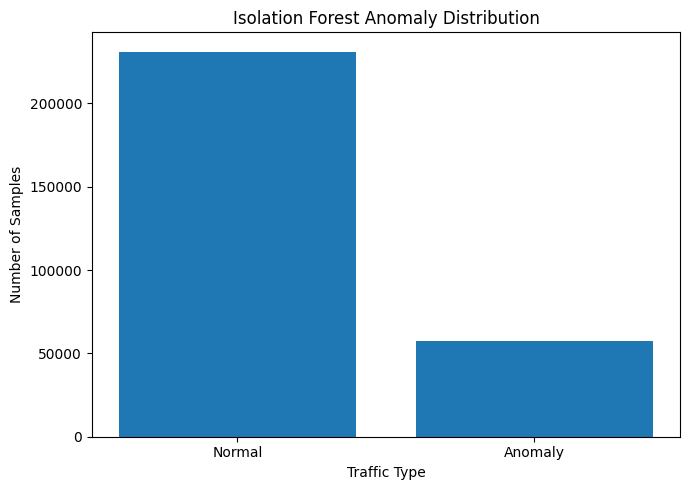

In [15]:
anomaly_counts = pd.Series(
    anomaly_labels
).value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal", "Anomaly"],
    [
        anomaly_counts.get(0, 0),
        anomaly_counts.get(1, 0)
    ]
)

plt.title("Isolation Forest Anomaly Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

In [16]:
actual_attacks = (y_all == 1)

detected_attacks = (
    (y_all == 1) &
    (anomaly_labels == 1)
)

attack_detection_rate = (
    detected_attacks.sum() /
    actual_attacks.sum()
)

print(
    f"Attack Detection Rate: "
    f"{attack_detection_rate:.4f}"
)

print(
    f"Attack Detection Rate: "
    f"{attack_detection_rate * 100:.2f}%"
)

Attack Detection Rate: 0.4228
Attack Detection Rate: 42.28%


In [18]:
import joblib
import os

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

isolation_model_path = os.path.join(
    model_dir,
    "isolation_forest_anomaly.joblib"
)

joblib.dump(
    isolation_model,
    isolation_model_path
)

print("Isolation Forest model saved successfully!")
print("Model path:", isolation_model_path)

Isolation Forest model saved successfully!
Model path: ../models\isolation_forest_anomaly.joblib
